# Figure 4 of Pierard2024TheTile: Toy examples for correlation tiles with a rank correlation

This jupyter notebook reproduces the nine tiles of Figure 4 in :cite:t:`Pierard2024TheTile'. The paper can be found [here](https://hdl.handle.net/2268/325533). 

It provides toy examples showing correlation tiles showing the rank correlations (Kendall τ ) between 9 probabilistic scores (those that belong to the ranking scores), and all ranking scores, for a uniform distribution of performances. 
The correlation values have been estimated based on 10,000 performances drawn at random.

In [ ]:
import matplotlib.pyplot as plt

from sorbetto.annotation import AnnotationText
from sorbetto.flavor import CorrelationFlavor
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.performance import PerformanceOrderingInducedByOneScore
from sorbetto.performance_distribution import (
    UniformDistributionOfTwoClassClassificationPerformances,
)
from sorbetto.ranking import Importance, RankingScore
from sorbetto.tile import CorrelationTile, Tile

In [2]:
# Choose the correlation function as a rank correlation with the Kendall Tau correlation
correlation_fct_name = "kendall_tau"

# Draw 10,000 performances at random
number_of_performances_drawn_at_random = 10000
performances_drawn_at_random = UniformDistributionOfTwoClassClassificationPerformances(
    "Uniform distribution of performances"
).drawAtRandom(number_of_performances_drawn_at_random)

In [3]:
def produce_correlation_tile(score, tile_name):
    match correlation_fct_name:
        case "pearson_r":
            flavor_name = "Correlation (Pearson's $r$)"
        case "spearman_rho":
            flavor_name = "Correlation (Spearman's $\\rho$)"
        case "kendall_tau":
            flavor_name = "Correlation (Kendall's $\\tau$)"
        case _:
            flavor_name = "Correlation"

    flavor = CorrelationFlavor(
        performances=performances_drawn_at_random,
        other_score=score,
        correlation_coefficient_name=correlation_fct_name,
        name=flavor_name,
    )
    tile = CorrelationTile(
        name=tile_name,
        parameterization=ParameterizationDefault(),
        flavor=flavor,
        resolution=101,
    )

    # Add a point displaying where the score is on the Tile as an annotation
    point_annotation = AnnotationText(
        location=score, label="", color="black", markersize="10"
    )
    tile.appendAnnotation(point_annotation)

    # Draw the Tile
    fig, ax = tile.draw()
    plt.show()
    return tile

## Negative Predictive Value $NPV$

100%|██████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:13<00:00,  7.24it/s]


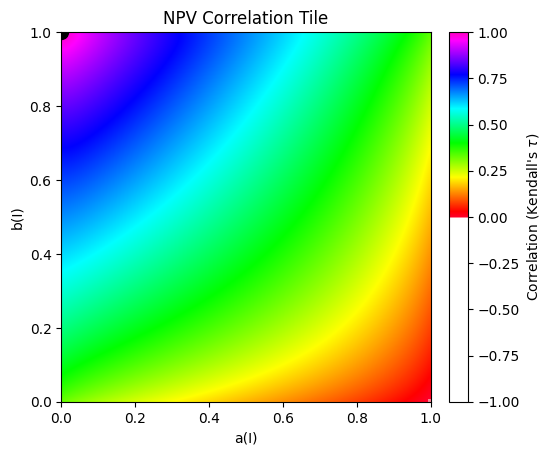

In [4]:
npv_score = RankingScore.getNegativePredictiveValue()
npv_correlation_tile = produce_correlation_tile(npv_score, "NPV Correlation Tile")

## $X^{C}_{\{tn,tp\}|\{tn,fn,tp\}}$

100%|██████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:13<00:00,  7.42it/s]


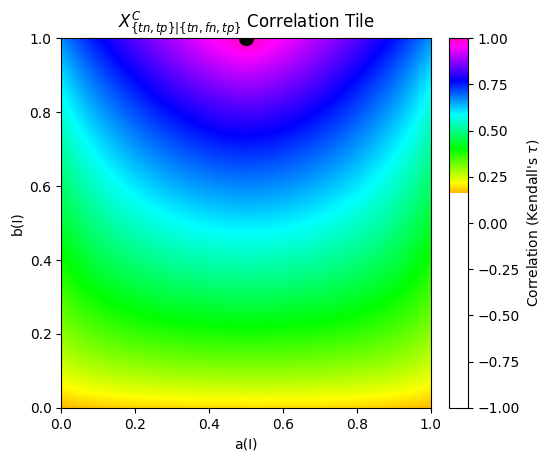

In [5]:
importance_score2 = Importance(itn=1, ifp=0, ifn=1, itp=1)
score2 = RankingScore(importance_score2, name="$X^{C}_{\\{tn,tp\\}|\\{tn,fn,tp\\}}$")
score2_correlation_tile = produce_correlation_tile(
    score2, "$X^{C}_{\\{tn,tp\\}|\\{tn,fn,tp\\}}$ Correlation Tile"
)

## True Positive Rate $TPR$

100%|██████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:15<00:00,  6.68it/s]


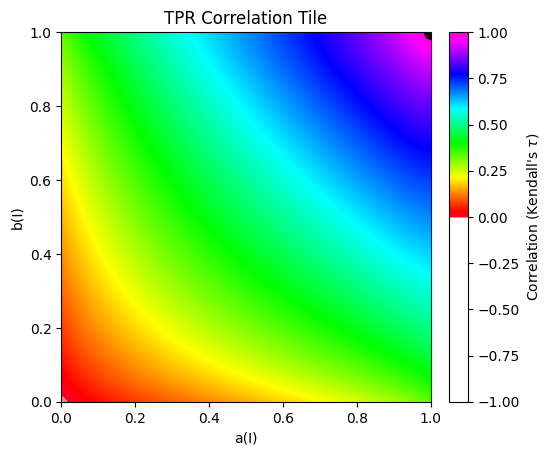

In [6]:
tpr_score = RankingScore.getTruePositiveRate()
tpr_correlation_tile = produce_correlation_tile(tpr_score, "TPR Correlation Tile")

## Inverse Jaccard $J_{-}$

100%|██████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:13<00:00,  7.29it/s]


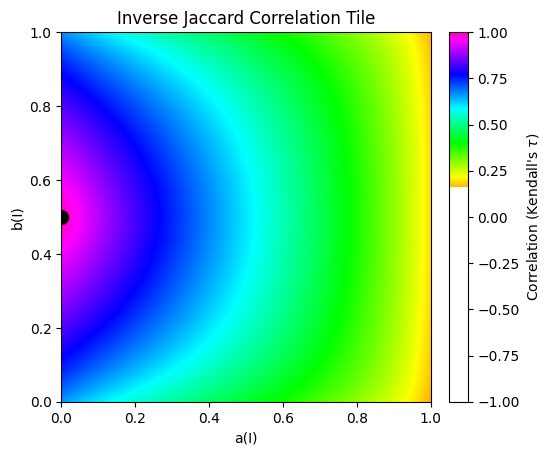

In [7]:
inverse_jaccard_score = RankingScore.getInverseJaccard()
inverse_jaccard_correlation_tile = produce_correlation_tile(
    inverse_jaccard_score, "Inverse Jaccard Correlation Tile"
)

## Accuracy $A$

100%|██████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:13<00:00,  7.51it/s]


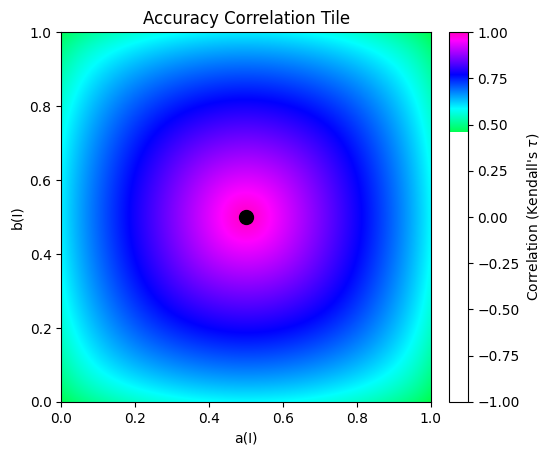

In [8]:
accuracy_score = RankingScore.getAccuracy()
accuracy_correlation_tile = produce_correlation_tile(
    accuracy_score, "Accuracy Correlation Tile"
)

## Jaccard $J_{+}$

100%|██████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:13<00:00,  7.30it/s]


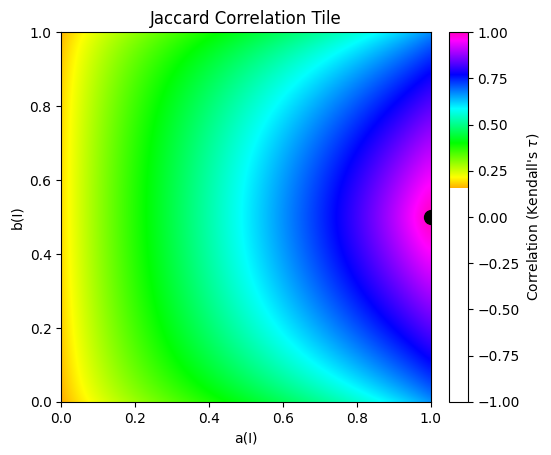

In [9]:
jaccard_score = RankingScore.getJaccard()
jaccard_correlation_tile = produce_correlation_tile(
    jaccard_score, "Jaccard Correlation Tile"
)

## True Negative Rate $TNR$

100%|██████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:13<00:00,  7.22it/s]


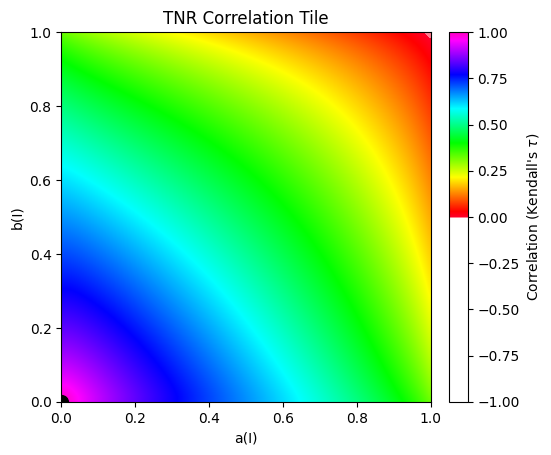

In [10]:
tnr_score = RankingScore.getTrueNegativeRate()
tnr_correlation_tile = produce_correlation_tile(tnr_score, "TNR Correlation Tile")

## $X^{C}_{\{tn,tp\}|\{tn,fp,tp\}}$

100%|██████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:13<00:00,  7.30it/s]


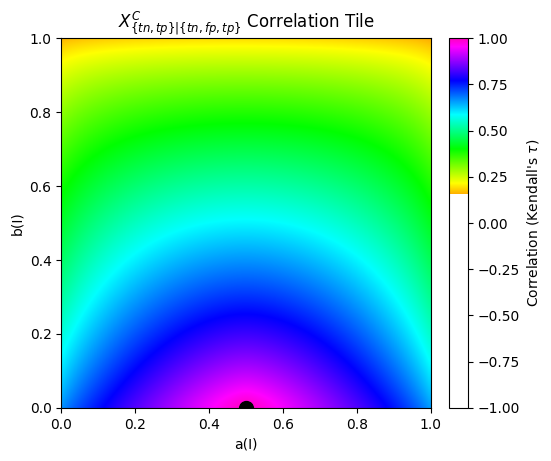

In [11]:
importance_score8 = Importance(itn=1, ifp=1, ifn=0, itp=1)
score8 = RankingScore(importance_score8, name="$X^{C}_{\\{tn,tp\\}|\\{tn,fp,tp\\}}$")
score8_correlation_tile = produce_correlation_tile(
    score8, "$X^{C}_{\\{tn,tp\\}|\\{tn,fp,tp\\}}$ Correlation Tile"
)

## Positive Predictive Value $PPV$

100%|██████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:14<00:00,  7.01it/s]


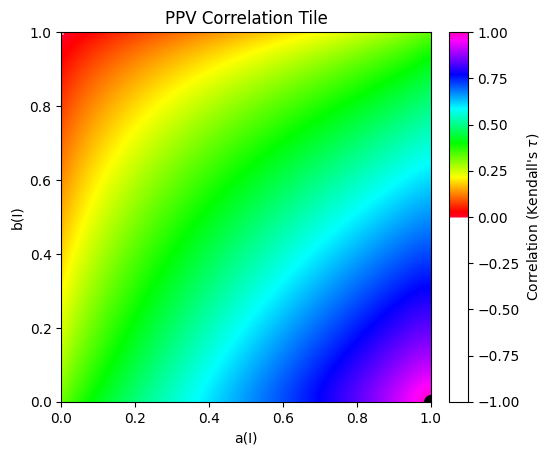

In [12]:
ppv_score = RankingScore.getPositivePredictiveValue()
ppv_correlation_tile = produce_correlation_tile(ppv_score, "PPV Correlation Tile")

## Summary

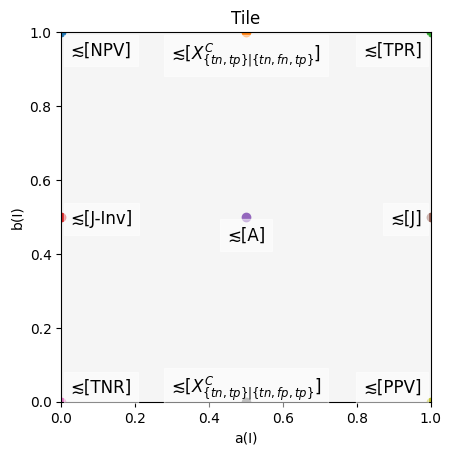

In [17]:
parameterization = ParameterizationDefault()
tile = Tile(parameterization)
scores = [
    npv_score,
    score2,
    tpr_score,
    inverse_jaccard_score,
    accuracy_score,
    jaccard_score,
    tnr_score,
    score8,
    ppv_score,
]
for score in scores:
    ordering = PerformanceOrderingInducedByOneScore(score)
    tile.appendAnnotation(AnnotationText(ordering, fontsize="12"))
tile.draw()
plt.show()

## Firgure 4 with the 9 Correlation Tiles

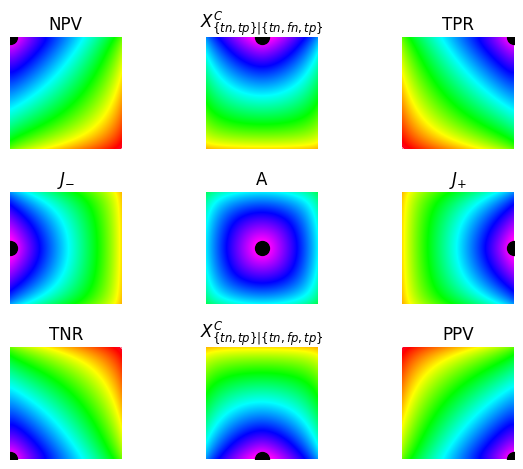

In [14]:
# Initialise the subplot figure and axis
figure, axis = plt.subplots(3, 3)

npv_correlation_tile.name = "NPV"
npv_correlation_tile.colorbar_mode = "off"
npv_correlation_tile.draw(fig=figure, ax=axis[0, 0])
axis[0, 0].axis("off")

score2_correlation_tile.name = "$X^{C}_{\\{tn,tp\\}|\\{tn,fn,tp\\}}$"
score2_correlation_tile.colorbar_mode = "off"
score2_correlation_tile.draw(fig=figure, ax=axis[0, 1])
axis[0, 1].axis("off")

tpr_correlation_tile.name = "TPR"
tpr_correlation_tile.colorbar_mode = "off"
tpr_correlation_tile.draw(fig=figure, ax=axis[0, 2])
axis[0, 2].axis("off")

inverse_jaccard_correlation_tile.name = "$J_{-}$"
inverse_jaccard_correlation_tile.colorbar_mode = "off"
inverse_jaccard_correlation_tile.draw(fig=figure, ax=axis[1, 0])
axis[1, 0].axis("off")

accuracy_correlation_tile.name = "A"
accuracy_correlation_tile.colorbar_mode = "off"
accuracy_correlation_tile.draw(fig=figure, ax=axis[1, 1])
axis[1, 1].axis("off")

jaccard_correlation_tile.name = "$J_{+}$"
jaccard_correlation_tile.colorbar_mode = "off"
jaccard_correlation_tile.draw(fig=figure, ax=axis[1, 2])
axis[1, 2].axis("off")

tnr_correlation_tile.name = "TNR"
tnr_correlation_tile.colorbar_mode = "off"
tnr_correlation_tile.draw(fig=figure, ax=axis[2, 0])
axis[2, 0].axis("off")

score8_correlation_tile.name = "$X^{C}_{\\{tn,tp\\}|\\{tn,fp,tp\\}}$"
score8_correlation_tile.colorbar_mode = "off"
score8_correlation_tile.draw(fig=figure, ax=axis[2, 1])
axis[2, 1].axis("off")

ppv_correlation_tile.name = "PPV"
ppv_correlation_tile.colorbar_mode = "off"
ppv_correlation_tile.draw(fig=figure, ax=axis[2, 2])
axis[2, 2].axis("off")

figure.tight_layout()
plt.show()